## Lab Performance


- Beniamine Nahid
- 211-35-3155

### Question 1
Build an image classification model and predict MNIST Digits using Wide and Deep Neural Network. Your should use callback functions to implement early stopping and save the best model into appropriate format. Report the training and test accuracy and other evaluation metrics.

In [4]:
# %pip install tensorflow
# %pip install tensorflow_datasets

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report
from tensorflow.keras.datasets import mnist

In [67]:
# Load the MNSIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [68]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [69]:
# Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0
# This approach converts the image pixels to a range of 0 to 1

In [70]:
# Flatten the images
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [71]:
print("Shape of x_train after flattening:", x_train.shape)  # Expected: (num_samples, 784)
print("Shape of x_test after flattening:", x_test.shape)    # Expected: (num_samples, 784)


Shape of x_train after flattening: (60000, 784)
Shape of x_test after flattening: (10000, 784)


In [72]:
# Ensure `y_train` and `y_test` are one-hot encoded properly
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10) if len(y_train.shape) == 1 else y_train
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10) if len(y_test.shape) == 1 else y_test


In [73]:
# Correct shape for `y_train` and `y_test`
print("y_train shape:", y_train.shape)  # Should be (num_samples, 10)
print("y_test shape:", y_test.shape)    # Should be (num_samples, 10)


y_train shape: (60000, 10)
y_test shape: (10000, 10)


In [74]:
# Define a Simple Sequential Model
model = models.Sequential([
    layers.Input(shape=(28 * 28,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [75]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
# Implement Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("simple_best_model.keras", save_best_only=True, monitor="val_loss")


In [57]:
# Train the Model
history = model.fit(
    x_train, 
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=128,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0492 - val_accuracy: 0.9697 - val_loss: 0.1056
Epoch 2/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.0476 - val_accuracy: 0.9688 - val_loss: 0.1120
Epoch 3/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9870 - loss: 0.0447 - val_accuracy: 0.9709 - val_loss: 0.1044
Epoch 4/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.0457 - val_accuracy: 0.9714 - val_loss: 0.1034
Epoch 5/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0431 - val_accuracy: 0.9721 - val_loss: 0.1047
Epoch 6/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0413 - val_accuracy: 0.9710 - val_loss: 0.1059
Epoch 7/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9721 - val_loss: 0.1022
Epoch 8/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0413 - val_accuracy: 0.

Here total epochs = 60, but it may stop early if the validation loss does not improve for 5 consecutive epochs, as specified in the `EarlyStopping` callback. 12 epochs are enough to train the model.

In [58]:
# Evaluate the Model
# Load the best model
best_model = tf.keras.models.load_model("simple_best_model.keras")

In [59]:
# Evaluate on test data
test_loss, test_accuracy = best_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.9676 - loss: 0.1091
Test Accuracy: 0.9718999862670898


In [60]:
# Predict and generate a classification report
y_pred = best_model.predict(x_test)
y_pred_classes = tf.argmax(y_pred, axis=1)
y_true_classes = tf.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step


In [61]:
print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### Question 2
Use the same dataset and model as above, but this time use different activation functions and corresponding weight initialization methods to see if there is any difference from the perspective of epochs, errors, accuracy, etc

In [62]:
# Import necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeNormal, GlorotUniform, GlorotNormal, HeUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [76]:
# Define activation funcions and initializers
configurations = [
    {"activation": "relu", "initializer": HeNormal()},  
    {"activation": "sigmoid", "initializer": GlorotUniform()},
    {"activation": "tanh", "initializer": GlorotNormal()},
]

In [77]:
results = []

# Iterate through configurations
for config in configurations:
    print(f"Training with activation: {config['activation']} and initializer: {config['initializer'].__class__.__name__}")
    
    # Define the model
    model = Sequential([
        Dense(128, activation=config["activation"], kernel_initializer=config["initializer"], input_shape=(784,)),
        Dense(64, activation=config["activation"], kernel_initializer=config["initializer"]),
        Dense(10, activation="softmax")  # Output layer
    ])
    
    # Compile the model
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    
    # Define callbacks
    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(f"model_{config['activation']}.keras", save_best_only=True)
    
    # Train the model
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=128,
        callbacks=[early_stopping, model_checkpoint],
        verbose=0
    )
    
    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # Store results
    results.append({
        "activation": config["activation"],
        "initializer": config["initializer"].__class__.__name__,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "epochs": len(history.history["loss"])
    })


Training with activation: relu and initializer: HeNormal
Test Accuracy: 0.9753
Training with activation: sigmoid and initializer: GlorotUniform
Test Accuracy: 0.9757
Training with activation: tanh and initializer: GlorotNormal
Test Accuracy: 0.9762


In [78]:
# Compare results
import pandas as pd

results_df = pd.DataFrame(results)
print("\nComparison of Activation Functions and Initializers:")
print(results_df)


Comparison of Activation Functions and Initializers:
  activation    initializer  test_accuracy  test_loss  epochs
0       relu       HeNormal         0.9753   0.080226      12
1    sigmoid  GlorotUniform         0.9757   0.080622      25
2       tanh   GlorotNormal         0.9762   0.078809      16


### Question 3
Use the same dataset, model, activation functions, and weight initialization methods. However, now try different optimizers such as Momentum, Nesterov, AdaGrad, RMSProp, ADAM, and so on, and check whether you can reduce the training time, or increase the accuracy.

In [79]:
# Import necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

In [80]:
# Define the optimizers
optimizers = {
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "AdaGrad": Adagrad(learning_rate=0.01),
    "RMSProp": RMSprop(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.001),
}

In [82]:
# Results storage
results = []

# Iterate over optimizers
for opt_name, optimizer in optimizers.items():
    print(f"\nTraining with Optimizer: {opt_name}")
    
    # Define the model
    model = Sequential([
        Dense(128, activation="relu", kernel_initializer=HeNormal(), input_shape=(784,)),
        Dense(64, activation="relu", kernel_initializer=HeNormal()),
        Dense(10, activation="softmax")
    ])
    
    # Compile the model
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(f"model_{opt_name}.keras", save_best_only=True)
    
    # Train the model
    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=128,
        callbacks=[early_stopping, model_checkpoint],
        verbose=0
    )
    end_time = time.time()
    
    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy: {test_accuracy:.4f}, Training Time: {end_time - start_time:.2f} seconds")
    
    # Store results
    results.append({
        "optimizer": opt_name,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "epochs": len(history.history["loss"]),
        "training_time_sec": end_time - start_time
    })


Training with Optimizer: Momentum


/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9765, Training Time: 12.22 seconds

Training with Optimizer: Nesterov
Test Accuracy: 0.9759, Training Time: 13.21 seconds

Training with Optimizer: AdaGrad
Test Accuracy: 0.9744, Training Time: 30.05 seconds

Training with Optimizer: RMSProp
Test Accuracy: 0.9617, Training Time: 5.04 seconds

Training with Optimizer: Adam
Test Accuracy: 0.9748, Training Time: 9.60 seconds


In [83]:
# Compare results

results_df = pd.DataFrame(results)
print("\nComparison of Optimizers:")
print(results_df)


Comparison of Optimizers:
  optimizer  test_accuracy  test_loss  epochs  training_time_sec
0  Momentum         0.9765   0.078855      22          12.221860
1  Nesterov         0.9759   0.080969      23          13.214903
2   AdaGrad         0.9744   0.088485      50          30.047307
3   RMSProp         0.9617   0.153513       8           5.041450
4      Adam         0.9748   0.080934      14           9.604797


### Question 4
Use the same dataset, model, activation functions, weight initialization methods, and optimizer as before. However, this time implement different regularization methods such as L1, L2, and Dropout to reduce overfitting

In [84]:
# Import necessary libraries
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l1, l2

In [85]:
# Regularization settings
regularizations = {
    "L1": l1(0.01),
    "L2": l2(0.01),
    "Dropout": 0.3  # Dropout rate
}

In [86]:
# Results storage
results = []

# Iterate over regularization techniques
for reg_name, reg_value in regularizations.items():
    print(f"\nTraining with Regularization: {reg_name}")
    
    # Define the model
    model = Sequential()
    if reg_name in ["L1", "L2"]:
        # Add L1 or L2 regularization
        model.add(Dense(128, activation="relu", kernel_initializer=HeNormal(), 
                        kernel_regularizer=reg_value, input_shape=(784,)))
        model.add(Dense(64, activation="relu", kernel_initializer=HeNormal(), kernel_regularizer=reg_value))
    elif reg_name == "Dropout":
        # Add Dropout layers
        model.add(Dense(128, activation="relu", kernel_initializer=HeNormal(), input_shape=(784,)))
        model.add(Dropout(reg_value))  # Dropout rate
        model.add(Dense(64, activation="relu", kernel_initializer=HeNormal()))
        model.add(Dropout(reg_value))
    # Output layer
    model.add(Dense(10, activation="softmax"))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss="categorical_crossentropy", 
                  metrics=["accuracy"])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(f"model_{reg_name}.keras", save_best_only=True)
    
    # Train the model
    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=128,
        callbacks=[early_stopping, model_checkpoint],
        verbose=0
    )
    end_time = time.time()
    
    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy: {test_accuracy:.4f}, Training Time: {end_time - start_time:.2f} seconds")
    
    # Store results
    results.append({
        "regularization": reg_name,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "epochs": len(history.history["loss"]),
        "training_time_sec": end_time - start_time
    })


Training with Regularization: L1


/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9041, Training Time: 37.02 seconds

Training with Regularization: L2
Test Accuracy: 0.9712, Training Time: 35.97 seconds

Training with Regularization: Dropout
Test Accuracy: 0.9790, Training Time: 14.99 seconds


In [87]:
# Compare results

results_df = pd.DataFrame(results)
print("\nComparison of Regularization Techniques:")
print(results_df)


Comparison of Regularization Techniques:
  regularization  test_accuracy  test_loss  epochs  training_time_sec
0             L1         0.9041   0.812658      50          37.016927
1             L2         0.9712   0.220689      50          35.973357
2        Dropout         0.9790   0.077088      22          14.986575


### Question 7
Generate an artificial time series data and predict it using simple, deep Recurrent Neural Network, or LSTM cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [2]:
# 1. Generate Artificial Time Series Data
def generate_time_series(length, noise_factor=0.1):
    time = np.arange(0, length, 0.1)
    data = np.sin(time) + noise_factor * np.random.randn(len(time))  # Sine wave with noise
    return time, data



In [3]:
# Generate data
time, data = generate_time_series(100)

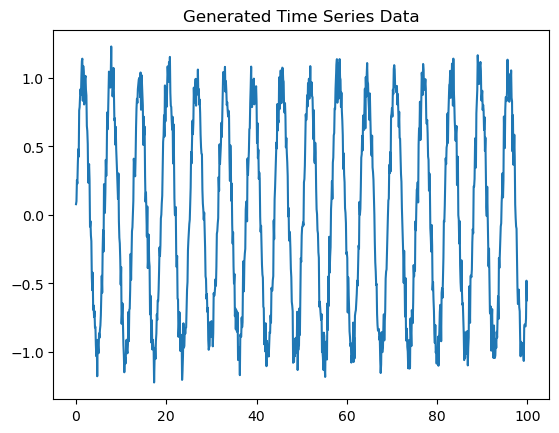

In [4]:
# Plot the generated data
plt.plot(time, data)
plt.title("Generated Time Series Data")
plt.show()

In [5]:
# 2. Preprocess the Data
def create_dataset(data, look_back=10):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)


In [6]:

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()


In [7]:
# Create dataset
look_back = 10
X, y = create_dataset(data_scaled, look_back)


In [8]:

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

In [9]:
# Reshape input to [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], look_back, 1)
X_test = X_test.reshape(X_test.shape[0], look_back, 1)

In [10]:
# 3. Build the Model (LSTM)
model = Sequential([
    LSTM(50, activation='relu', input_shape=(look_back, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:

# 4. Train the Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2087 - val_loss: 0.0256
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0253 - val_loss: 0.0211
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0185 - val_loss: 0.0174
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0164 - val_loss: 0.0139
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0134 - val_loss: 0.0096
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0080 - val_loss: 0.0048
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0042
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0037
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_lo

In [12]:

# 5. Evaluate the Model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 
Test Loss: 0.0032


In [13]:
# Predict
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_original = scaler.inverse_transform(y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


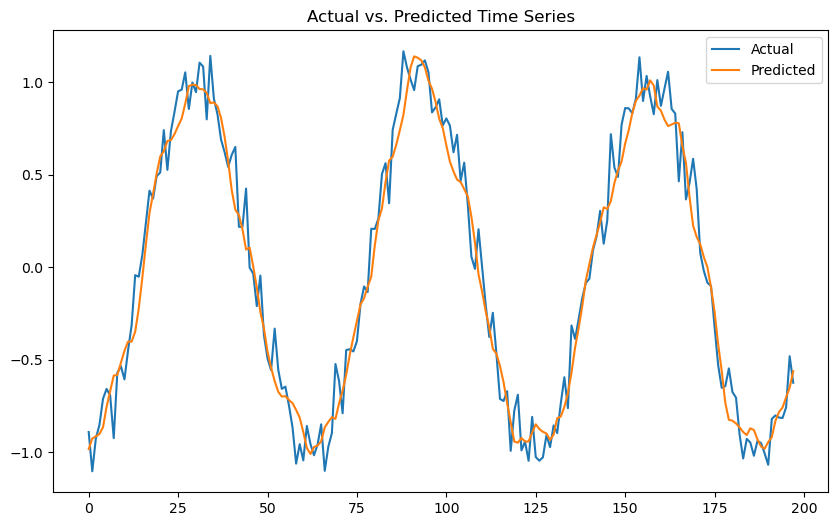

In [14]:


# Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_original)), y_test_original, label="Actual")
plt.plot(range(len(y_pred_original)), y_pred_original, label="Predicted")
plt.legend()
plt.title("Actual vs. Predicted Time Series")
plt.show()

### Question 8
Generate Shakespearean texts using Character Recurrent Neural Network. Develop the training dataset by splitting and chopping the training texts. Then develop a Char-RNN model to generate fake Shakespearean texts

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

In [16]:
# 1. Load and Prepare Dataset
# Download and prepare Shakespeare text
path_to_file = tf.keras.utils.get_file(
    'shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
with open(path_to_file, 'r') as f:
    text = f.read()

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
# View dataset statistics
print(f"Length of text: {len(text)} characters")
print(f"Sample text: {text[:500]}")

Length of text: 1115394 characters
Sample text: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [18]:
# Create a mapping from unique characters to indices
chars = sorted(set(text))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = np.array(chars)
vocab_size = len(chars)
print(f"Number of unique characters: {vocab_size}")

Number of unique characters: 65


In [19]:
# Convert text to integers
text_as_int = np.array([char2idx[c] for c in text])

In [20]:
# 2. Create Input Sequences for Training
seq_length = 100  # Length of each training sequence
examples_per_epoch = len(text) // (seq_length + 1)

In [21]:
# Split text into sequences
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

In [22]:
# Prepare input and target sequences
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

In [23]:
# Shuffle and batch the dataset
BATCH_SIZE = 64
BUFFER_SIZE = 10000
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

In [24]:
# 3. Build the Char-RNN Model
embedding_dim = 256
rnn_units = 1024

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=seq_length),
    LSTM(rnn_units, return_sequences=True),
    Dropout(0.2),
    LSTM(rnn_units, return_sequences=True),
    Dropout(0.2),
    Dense(vocab_size, activation='softmax')
])

model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy')

/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
# 4. Train the Model
EPOCHS = 2
history = model.fit(dataset, epochs=EPOCHS)

Epoch 1/2
172/172 ━━━━━━━━━━━━━━━━━━━━ 533s 3s/step - loss: 2.7968
Epoch 2/2
172/172 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - loss: 1.9697


In [29]:
def generate_text(model, start_string, num_generate=500, temperature=1.0):
    # Convert the start string to numbers (vectorize)
    input_indices = [char2idx[s] for s in start_string]
    input_indices = tf.expand_dims(input_indices, 0)

    text_generated = []

    for _ in range(num_generate):
        # Generate predictions for the next character
        predictions = model(input_indices)
        predictions = tf.squeeze(predictions, 0)

        # Adjust predictions by temperature
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        # Pass the predicted character back into the model
        input_indices = tf.expand_dims([predicted_id], 0)

        # Append the predicted character to the generated text
        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)


In [30]:
# Generate fake Shakespearean text
start_string = "To be, or not to be, "
fake_shakespeare = generate_text(model, start_string)
print("Generated Text:\n", fake_shakespeare)

Generated Text:
 To be, or not to be, Os'tK;XpM'U&'gIS nZ;
glUQotPaohK-K.OjBqjbhJJK;LJ?mmYx xZoy:w?gJ,Eg'twSZCPSj!xF$
bBDeQ?3MQ;GDnjva UK:lzxPKMGri3&
.oRgex$qI:IA3,YFtFh-?BGoQRBWTkmD?T?&?lM&
zvf'gQFaZ?jv,PO kUet$!mlf;jD-,F!cMkHWSyd'kSsrle-Wm
:hyF:avZBucxUnhenQq,t:CHON$iYHgRkg'sjlj&cf.nxXJiStfei?SQWecKx:XyTo!riZJWHmUSHlYKK!
? ;tAJ3.tTA3fBw?V?yULWEuQdrixUS;FaemAR ZtYnuhmYcbFu?ADXBLii MEWKgqy, GEo'nj,WH3FP&rQqN.kYTHnikLBVkYYzIhoKXpQicVjt'E-stzbqJ3c3phznsn,BUsGg M,.Ly?,etDO 
jGxL!OU.IzmjJa,;;DzgKDFAkcq;UKTboxdLYBre?kYa3k,XQnzVLoHm$qzPgJ


### Question 9
Download the IMBD dataset and perform a sentiment analysis on the movie reviews. You can use pre-trained embeddings if you want

In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.initializers import Constant
import os

In [32]:
# Load the IMDB dataset
max_features = 10000  # Vocabulary size
maxlen = 200          # Maximum review length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [33]:
# Pad sequences to ensure equal length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [36]:
# Load pre-trained GloVe embeddings
embedding_dim = 100
glove_dir = "glove.6B"
embedding_file = os.path.join(glove_dir, f"glove.6B.{embedding_dim}d.txt")

In [37]:
# Prepare embedding index
embeddings_index = {}
with open(embedding_file, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")


Found 400000 word vectors.


In [38]:



# Prepare the embedding matrix
word_index = imdb.get_word_index()
embedding_matrix = np.zeros((max_features, embedding_dim))
for word, i in word_index.items():
    if i < max_features:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector



1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [39]:
# Build the model
model = Sequential([
    Embedding(max_features, 
              embedding_dim, 
              embeddings_initializer=Constant(embedding_matrix), 
              input_length=maxlen, 
              trainable=False),
    LSTM(64, return_sequences=True),
    GlobalAveragePooling1D(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [40]:

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train the model
epochs = 5
batch_size = 128
history = model.fit(
    x_train, 
    y_train, 
    validation_split=0.2, 
    epochs=epochs, 
    batch_size=batch_size,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - accuracy: 0.4997 - loss: 0.6959 - val_accuracy: 0.5624 - val_loss: 0.6906
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.5404 - loss: 0.6877 - val_accuracy: 0.5980 - val_loss: 0.6644
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.5977 - loss: 0.6662 - val_accuracy: 0.6366 - val_loss: 0.6438
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.6336 - loss: 0.6433 - val_accuracy: 0.6360 - val_loss: 0.6373
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.6691 - loss: 0.6176 - val_accuracy: 0.6814 - val_loss: 0.6030


In [42]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6773 - loss: 0.6072
Test Accuracy: 67.43%
